In [32]:
# imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

# <div align="center">**The Planet in a Box: An Energy Balance Model of Global Warming**</div>

### <div align="center">MOD300 Mandatory project #2 </div>

<div align="center">Written by Jone Bakken & Petter Worpvik Tverdal</div>

<br>

<div align="center"> October 4th, 2026 </div>

## Abstract

To study how the global temperature responds to changes in $\text{CO}_2$, we use a two-box energy balance model. First, we check the units of the model and calculate the temperature of an Earth without an atmosphere, which gives $T_{eq}\approx254.6$ K, or $-18.6\ ^\circ\text{C}$. Then, we build our own ODE solver with Forward Euler and RK4. The solver reaches the equilibrium we found by hand, gives an equilibrium climate sensitivity of 3.28 K, which is inside the IPCC range of 2.5 to 4 °C, and agrees with SciPy's Radau solver within $3.3\cdot10^{-5}$ K. Forward Euler becomes unstable for time steps between 7 and 8 years, while RK4 stays stable for all the steps we tested.

Next, we fit the model to observed temperatures from 1959 to 2025. Fitting both $\lambda$ and $\gamma$ gives a small error, but the parameters are not physical. With $\gamma$ fixed, the ECS becomes $1.77\ ^\circ\text{C}$, which is below the IPCC range, and the residuals are clearly systematic. Adding an aerosol cooling removes this pattern and lowers the RMSE from $0.209\ ^\circ\text{C}$ to $0.096\ ^\circ\text{C}$.

Finally, we add an ice-albedo feedback that makes the model nonlinear. With this feedback, a temporary $\text{CO}_2$ increase with a peak above a threshold between 320 and 340 ppm pushes the model into a warm state at about 5.2 K, which it stays in even after the $\text{CO}_2$ is back at the pre-industrial level.

## Introduction

In this project, we use a two-box energy-balance model to show how the climate responds to changes in greenhouse gas forcing, how quickly temperatures adjust, and how the response changes when forcing is reduced. We apply several ideas from mathematical modelling: translating conservation laws into ordinary differential equations, implementing a reusable numerical solver, and comparing numerical results to known behavior and an independent method.

The two-box model has an upper box for the atmosphere and upper ocean, which responds quickly, and a lower box for the deep ocean, which responds slowly because of its large heat capacity [[1]](#source-1). The temperatures $T$ and $T_0$ are anomalies relative to the pre-industrial equilibrium. The model is a simplification, but it still shows the combined effect of forcing, radiative damping and heat exchange between the boxes.

Firstly, we will explain the physical meaning and units of the energy balances, then calculate the equilibrium temperature of an idealized Earth without an atmosphere. Then, we implement a general ODE solver and validate this using what we know from the equilibrium, a SciPy solution, and a time step stability analysis.

After this, we use the model on real observations. We make the forcing from the measured $\text{CO}_2$ concentration at Mauna Loa, and fit the parameters $\lambda$ and $\gamma$ to the global temperature record from NASA, using SciPy's `curve_fit`. The residuals are then used to see if the model fails in a systematic way. Next, we add a cooling from aerosols to the forcing, and check if this explains what the $\text{CO}_2$-only model is missing, by comparing the fits, residuals and errors of the two models.

We conclude the report by introducing a nonlinear feedback with ice albedo to look at system thresholds and hysteresis.

## 1. Fundamentals of the two-box model

The energy balances [[1]](#source-1) for the upper and lower boxes are:

$$ C \frac{dT}{dt} = F(t) - \lambda T - \gamma (T-T_0) \tag{1}$$
$$ C_0 \frac{dT_0}{dt} = \gamma (T-T_0) \tag{2}$$

We will first draw energy flows and check the units, then look at the radiative equilibrium for an idealized Earth without an atmosphere.

### 1.1 Visualizing the model

To correctly identify the energy flows, we need to understand what the variables mean:
- The forcing $F(t)$ is the external energy added to the climate system.
- Radiative damping, $-\lambda T$, is the energy lost as the system heats up. It is a stabilizing effect, meaning that a higher temperature $T$, leads to more energy removed.
- Heat exchange $\gamma (T-T_0)$ is the physical flow of heat between the mixed layer and deep ocean.

<figure align="center">
    <img src="figures/1.1-energy-flow.png" width="700">
    <figcaption style="text-align: left"> Figure 1: Energy flow of the approximated two-box model, showing directions of the forcing, radiative damping and heat exchange. </figcaption>
</figure>

The arrows show the chosen directions for the energy flows. In the upper-box balance (1), $+F(t)$ adds energy, so its arrow points into the upper box. The terms $-\lambda T$ and $-\gamma(T-T_0)$ remove energy when $T>0$ and $T>T_0$, so the radiative damping arrow points up to space and the heat exchange arrow points down into the deep ocean. If $T_0>T$, the heat exchange arrow reverses.

The heat-exchange terms have opposite signs in equations (1) and (2). When the equations are added, these terms cancel, showing that heat exchange transfers energy between the boxes but does not create or remove energy from the two-box system.

### 1.2 Checking the units

We now check that the terms in the two-box equations have consistent units, and use this to find the time unit of the model.

The temperatures $T$ and $T_0$ are temperature anomalies measured in Kelvin. Their rates of change have units $\frac{K}{\text{time}}$. The energy flow terms $F(t)$, $\lambda T$ and $\gamma (T-T_0)$ are measured in energy flow per unit area: $\frac{W}{m^{2}}$.

Using equation (1) and the units we already know, we can determine the unit of heat capacity in the upper box, $C$:

$$ [C] \cdot [\frac{dT}{dt}] = [F(t) - \lambda T - \gamma (T-T_0)] $$

$$ \implies [C] = \frac {W/m^2} {K / \text{time}} = \frac{W}{m^2} \cdot \frac{\text{time}}{K}
= \frac{W\cdot \text{time}}{m^2 \cdot K} $$

With equation (2) we can confirm that the units of heat capacities match:

$$ [C_0] = \frac{[\gamma (T-T_0)]}{[dT_0/dt]} $$
$$ \implies [C_0] = \frac{W/m^2}{K/\text{time}} = \frac{W\cdot \text{time}}{m^2 \cdot K} = [C]$$

Comparing this with the given values of $C$ and $C_0$ [[1](#source-1), [2](#source-2)], which are in units of $\frac{W \cdot \text{yr}}{m^2 \cdot K}$, shows that the model's time unit is years.

Since time is measured in years, all time arrays and step sizes in the solver are also given in years.

### 1.3 Solar constant and planetary albedo

Going forward in this chapter, we consider a simplified Earth without an atmosphere, radiating as a simple blackbody straight to space without trapping heat. The result will show why a climate model needs more than this simple blackbody radiation.

The solar constant $S_0 = 1361 W/m^2$ is the incoming solar power per unit area at Earth's average distance from the Sun [[1](#source-1), [2](#source-2)]. It describes the solar energy available at the top of the atmosphere before any reflection or absorption.

The planetary albedo $\alpha = 0.30$ is the fraction of solar radiation that is reflected back to space [[1](#source-1), [2](#source-2)]. Bright surfaces, like clouds, ice, and snow have a high albedo. In calculations, we are usually interested in the remaining fraction $(1-\alpha)$, which is the fraction of sunlight that is absorbed and can heat the planet.

### 1.4 Absorbed solar power

Figure 2 shows how sunlight reaches the Earth. The Sun is so far away that its rays arrive almost parallel, so the Earth blocks the sunlight like a flat disk facing the Sun, with the same radius $R$ as the Earth. The area that catches sunlight is therefore the area of this disk, not the whole sphere:

$$A=\pi R^2.$$

<figure align="center">
    <img src="figures/1.4-disk-sphere.png" width="550">
    <figcaption style="text-align: left"> Figure 2: Sunlight is caught by the Earth's cross-section, a disk with area πR², while thermal radiation is emitted from the whole sphere with area 4πR² <a href="#source-1">[1]</a>. </figcaption>
</figure>

The solar constant $S_0$ gives the power per unit area hitting this disk. As explained, the fraction $(1-\alpha)$ is absorbed, while the rest is reflected. Multiplying the incoming flux $S_0$ by $(1-\alpha)$ and by the area $A=\pi R^2$ gives the total absorbed power:

$$ P_{abs} = S_0 \cdot (1-\alpha) \cdot A = S_0(1-\alpha) \cdot \pi R^2$$

### 1.5 Radiative equilibrium

Unlike the incoming sunlight, the Earth emits heat from its entire surface, not just one side, as shown in Figure 2. Assuming the earth is a sphere, the total surface area is $4 \pi R^2$. With a power emitted per unit area of $\sigma T^4$, the total power is: 

$$P_{emit} = 4 \pi R^2 \sigma T^4$$

$T$ here is an absolute temperature in Kelvin, not a temperature anomaly as in the two-box model. 

Inserting $P_{abs}$ from earlier gives:

$$S_0(1-\alpha) \pi R^2 = \sigma T_{eq}^4 \cdot 4 \pi R^2$$

Since the area $\pi R^2$ appears on both sides, we can cancel it and get a way to solve for the equilibrium temperature, $T_{eq}$:

$$\sigma T_{eq}^4 = \frac{S_0(1-\alpha)}{4}$$
$$\implies T_{eq} = \left( \frac{S_0(1-\alpha)}{4\sigma} \right) ^{1/4}$$

To check the units, $S_0$ is in $W/m^2$ and $\alpha$ has no unit, so the numerator has units $W/m^2$. The Stefan-Boltzmann constant $\sigma$ has units $W/(m^2K^4)$, so dividing gives units of $K^4$. Taking the fourth root gives units of $K$, confirming that the equilibrium temperature is in Kelvin.

### 1.6 Interpreting the cold-Earth result

Substituting $S_0 = 1361 W/m^2$, $\alpha = 0.30$, and $\sigma = 5.670 \cdot 10^{-8} \frac{W}{(m^2 K^4)}$ gives

$$ T_{eq} = \left(  \frac{1361 \cdot (1-0.30)}{4 \cdot (5.670 \cdot 10^{-8})} \right)^{1/4} \approx 254.6 \text{ K}$$

Converting to degrees Celsius:

$$ T_{eq} \approx 254.6 - 273.15 = -18.6^\circ \text{C}$$

The observed global mean surface temperature [[1]](#source-1) is about $288 \text{ K}$, which is about $15 ^\circ \text{C}$. It is $33.4 \text{ K}$  warmer than our calculated $T_{eq} = 254.6 \text{ K}$.

The difference is mainly caused by the greenhouse effect. This means that the real atmosphere absorbs a lot of the radiation emitted by the surface, and sends some of it back down. Therefore, the surface must be warmer than $T_{eq}$ if the planet should emit the same amount of energy to space as it absorbs. The $33.4 \text{ K}$ difference shows why a realistic climate model needs to include the atmosphere, not only absorbed sunlight and blackbody emission.

### 1.7 Conclusion

The forcing $F(t)$ adds energy to the upper box, radiative damping $\lambda T$ removes it to space, and the exchange term $\gamma(T-T_0)$ moves heat between the boxes. The unit check showed that the equations are consistent, and that time in the model is measured in years. Without an atmosphere, the Earth would be about $-18.6\ ^\circ\text{C}$, which is 33 K colder than observed and shows why the atmosphere must be included in a climate model.

## 2. Building the ODE solver

After establishing the physical meaning and units of the two-box model, we can now translate it into a reusable numerical solver. We first formulate and test the solver, then check its equilibrium and compare the solution with SciPy. Finally, we use a varied step size in the Forward Euler method to compare with 4th order Runge-Kutta to find numerical instability.

### 2.1 Formulating the model and implementing a solver

We define the state vector as $\text{y}=(T,T_0)$. Dividing equations (1) and (2) by their heat capacities gives:

$$
\frac{d\text{y}}{dt}=\text{f}(\text{y},t)=
\begin{bmatrix}
\bigl(F(t)-\lambda T-\gamma(T-T_0)\bigr)/C \\
\gamma(T-T_0)/C_0
\end{bmatrix}
$$

We can then generalize this to an ODE of the form:

$$ \frac{d\text{y}}{dt}=\text{f}(\text{y},t,*\text{args}),$$

where the right hand side is the rate of change, and $\text{*args}$ allows for any additional model parameters or forcing functions needed. The reusable solver does not need any details of the climate model, it simply accepts the derivative function, initial state, time array and additional arguments. It uses each actual interval $h_i=t_{i+1}-t_i$.

The model is implemented in the following code, using a class to store the parameters:

In [33]:
class TwoBoxModel:
    """
    Stores the default parameters of the two-box energy balance model.

    C: heat capacity of the upper box (atmosphere + ocean mixed layer), W yr/(m^2 K)
    C0: heat capacity of the lower box (deep ocean), W yr/(m^2 K)
    lam: radiative damping parameter lambda, W/(m^2 K)
    gamma: heat exchange coefficient between the boxes, W/(m^2 K)

    The object is passed to ebm_rhs through *args. Parameters can be changed
    on the object, e.g. model.lam = 1.0, without changing the solver.
    """
    def __init__(self):
        self.C = 7.3
        self.C0 = 106.0
        self.lam = 1.13
        self.gamma = 0.73


def ebm_rhs(y, t, model, forcing):
    T, T0 = y
    F = forcing(t)
    dT_dt = (F - model.lam * T - model.gamma * (T - T0)) / model.C
    dT0_dt = model.gamma * (T - T0) / model.C0
    return np.array([dT_dt, dT0_dt])


def euler_step(f, delta_t, y_old, t_old, *args):
    return delta_t * f(y_old, t_old, *args)


def rk4_step(f, delta_t, y_old, t_old, *args):
    k1 = delta_t * f(y_old, t_old, *args)
    k2 = delta_t * f(y_old + 0.5 * k1, t_old + 0.5 * delta_t, *args)
    k3 = delta_t * f(y_old + 0.5 * k2, t_old + 0.5 * delta_t, *args)
    k4 = delta_t * f(y_old + k3, t_old + delta_t, *args)
    return (k1 + 2 * k2 + 2 * k3 + k4) / 6


def solver(f, y0, t, *args, method="RK4"):
    """
    f: right hand side of ODE f(y, t, *args)
    y0: initial condition at time t[0]
    t: array of time values (the spacing does not have to be equal)
    *args: arguments to f
    method: 'Euler' or 'RK4'

    return solution array with shape (len(t), len(y0))
    """
    if method == "Euler":
        step = euler_step
    elif method == "RK4":
        step = rk4_step
    else:
        print("Method not implemented.")
        return

    y = [y0]  # list to store the solution
    y_old = y0
    for i in range(len(t) - 1):
        delta_t = t[i + 1] - t[i]  # actual interval for this step
        y_new = y_old + step(f, delta_t, y_old, t[i], *args)
        y.append(y_new)
        y_old = y_new
    return np.array(y)


def test_forcing(time):
    return 4.0


# Short test if it works when time steps are unevenly spaced.
model = TwoBoxModel()
y0 = np.array([0.0, 0.0])
t_short = np.array([0.0, 0.25, 0.75, 1.0])
solution_rk4 = solver(ebm_rhs, y0, t_short, model, test_forcing, method="RK4")
solution_euler = solver(ebm_rhs, y0, t_short, model, test_forcing, method="Euler")

print("Shape of RK4:", solution_rk4.shape, " Shape of Euler:", solution_euler.shape)
print("Initial state:", y0)
print("First row RK4:", solution_rk4[0], " First row Euler:", solution_euler[0])

Shape of RK4: (4, 2)  Shape of Euler: (4, 2)
Initial state: [0. 0.]
First row RK4: [0. 0.]  First row Euler: [0. 0.]


The short test uses a nonuniform time array and runs both Euler and RK4. For each method, the solution has shape $(4,2)$, and its first row matches the supplied initial state. 

With the check complete, we will test whether the solver reproduces the model equilibrium we know, under constant forcing.


### 2.2 Equilibrium and solver validation

Now that the solver is built, we check that it gives the right answers. First, we find the temperatures the model should end up at under a constant forcing $F_0$. At equilibrium the temperatures no longer change, so we set the derivatives equal to zero.

The lower box only changes through heat exchange with the upper box:

$$
0=\gamma(T_{eq}-T_{0,eq}) \quad\Longrightarrow\quad T_{eq}=T_{0,eq}
$$

Since $\gamma\ne0$, the heat flow only stops when the two boxes have the same temperature. The exchange term in the upper-box balance is then zero, which gives:

$$
0=F_0-\lambda T_{eq} \quad\Longrightarrow\quad T_{eq}=T_{0,eq}=\frac{F_0}{\lambda}
$$

At equilibrium, the energy added by the forcing equals the energy radiated to space. The heat capacities do not appear in the result: they decide how fast the boxes reach equilibrium, but not where it is.

The forcing from a $\text{CO}_2$ concentration $c$ (in ppm) is given by the forcing law $F=5.35\ln(c/280)$ [[3]](#source-3), where 280 ppm is the pre-industrial level. For a $\text{CO}_2$ doubling, $c=560$ ppm, the forcing is therefore $F_{2\times}=5.35\ln 2$.

The equilibrium climate sensitivity (ECS) is the warming we get after doubling $\text{CO}_2$ and waiting until the temperatures settle:

$$
\mathrm{ECS}=\frac{F_{2\times}}{\lambda}
$$

In [34]:
def co2_forcing(c):
    return 5.35 * np.log(c / 280.0)  # forcing law, c in ppm


def constant_forcing(time):
    return co2_forcing(560.0)  # CO2 doubling


F2x = constant_forcing(0)
T_equilibrium = F2x / model.lam  # equal to the ECS

print("F2x =", round(F2x, 3), "W/m^2")
print("ECS =", round(T_equilibrium, 2), "K")

F2x = 3.708 W/m^2
ECS = 3.28 K


With the default $\lambda=1.13  \text{W}/(m^2 \text{K})$ [[1](#source-1), [2](#source-2)], we get $\text{ECS}\approx3.28 \text{ K}$. Since a change of $1 \text{K}$ is the same as a change of $1^\circ \text{C}$, this is $3.28 ^\circ \text{C}$, which lies within the IPCC AR6 [[4]](#source-4)  range of $2.5$ - $4 ^\circ \text{C}$. The default parameters therefore give a realistic climate sensitivity.

Next, we check the solver. Starting with both temperatures at zero, we run RK4 for 3000 years with a step of 1 year, and again with 0.5 years. The two boxes respond very differently: the upper box changes within a few years, while the deep ocean needs several hundred years because of its large heat capacity. 3000 years is therefore long enough for both boxes to reach equilibrium. We compare both runs with the reference solver `solve_reference` [[1]](#source-1). It uses SciPy's `solve_ivp` with the Radau method and strict error tolerances, and takes the same arguments and returns the same shape as our solver, so the results can be compared. We also run both solvers on the short, uneven time array from 2.1, to check that our solver uses the actual time intervals correctly.

Uneven t_short: max difference from Radau = 5.869203906772036e-07 K
h = 1.0 yr: max difference from Radau = 3.262029495187946e-05 K
h = 0.5 yr: max difference from Radau = 1.8299909960717287e-06 K
Temperatures after 3000 years (T, T_0): [3.28170914 3.28170103] K


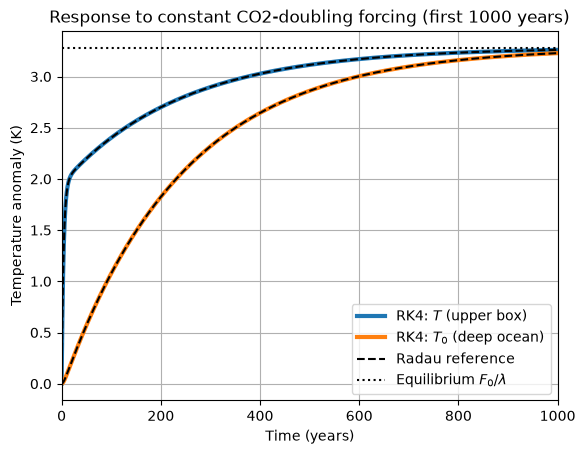

In [35]:
# Reference solver supplied in the project description
def solve_reference(f, y0, t, *args):
    def scipy_rhs(time, state):
        return f(state, time, *args)

    sol = solve_ivp(
        scipy_rhs,
        (t[0], t[-1]), y0, method="Radau", t_eval=t,
        rtol=1e-8, atol=1e-10,
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol.y.T


# Short uneven time array from 2.1, compared with Radau
print("Uneven t_short: max difference from Radau =", np.max(np.abs(solver(ebm_rhs, y0, t_short, model, test_forcing) - solve_reference(ebm_rhs, y0, t_short, model, test_forcing))), "K")

for h in [1.0, 0.5]:
    t = np.arange(0, 3000 + h, h)
    solution_rk4 = solver(ebm_rhs, y0, t, model, constant_forcing, method="RK4")
    reference = solve_reference(ebm_rhs, y0, t, model, constant_forcing)
    print("h =", h, "yr: max difference from Radau =", np.max(np.abs(solution_rk4 - reference)), "K")

print("Temperatures after 3000 years (T, T_0):", solution_rk4[-1], "K")

plt.plot(t, solution_rk4[:, 0], label="RK4: $T$ (upper box)", linewidth=3)
plt.plot(t, solution_rk4[:, 1], label="RK4: $T_0$ (deep ocean)", linewidth=3)
plt.plot(t, reference[:, 0], "k--", label="Radau reference")
plt.plot(t, reference[:, 1], "k--")
plt.axhline(T_equilibrium, color="k", linestyle=":", label="Equilibrium $F_0/\\lambda$")
plt.xlim(0, 1000)
plt.xlabel("Time (years)")
plt.ylabel("Temperature anomaly (K)")
plt.title("Response to constant CO2-doubling forcing (first 1000 years)")
plt.legend()
plt.grid()
plt.show()

Figure 3: Upper box and deep ocean temperature under constant $\text{CO}_2$-doubling forcing, with RK4 compared to the Radau reference solver.

After 3000 years, both temperatures are $3.2817 \text{ K}$, the same as $F_0 / \lambda$. The solver therefore reaches the equilibrium we derived by hand.

The figure shows the first 1000 years, where the changes happen. The upper box warms to about $2 \text{ K}$ very fast, while the deep ocean, with a much larger heat capacity, warms slowly over the years. The dashed Radau curves are on top of the RK4 curves.

The differences between RK4 and Radau are also printed above. We got the biggest difference of $3.3\cdot 10^{-5} \text{ K}$ with a step size of 1 year, and $1.8 \cdot 10^{-6} \text{ K}$ with a 0.5 year step. Halving the step makes the error about 18 times smaller. This fits with RK4 being a fourth-order method, where the error is proportional to $h^4$, so halving the step should make it about $2^4=16$ times smaller. On the short, uneven time array from 2.1, the difference is only $5.9\cdot 10^{-7} \text{ K}$, which shows that the solver handles uneven steps correctly.

### 2.3 Investigating solver stability

The previous checks confirm the model and RK4 solver work at a stable step size. Now, we vary the step size to compare Forward Euler with RK4. This helps us tell whether any oscillation or growth comes from the numerical method rather than from the physical model.

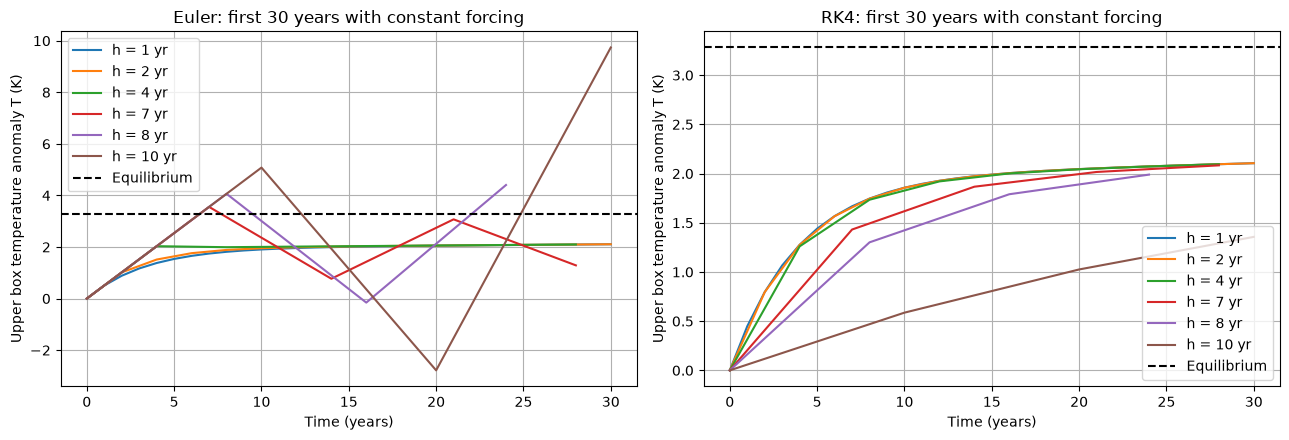

Euler h = 1 yr: max T = 2.11 K
Euler h = 2 yr: max T = 2.11 K
Euler h = 4 yr: max T = 2.1 K
Euler h = 7 yr: max T = 3.56 K
Euler h = 8 yr: max T = 4.4 K
Euler h = 10 yr: max T = 9.74 K
RK4 h = 1 yr: max T = 2.11 K
RK4 h = 2 yr: max T = 2.11 K
RK4 h = 4 yr: max T = 2.1 K
RK4 h = 7 yr: max T = 2.08 K
RK4 h = 8 yr: max T = 1.99 K
RK4 h = 10 yr: max T = 1.36 K


In [36]:
step_sizes = [1, 2, 4, 7, 8, 10]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
results = []  # printed after the plots

for ax, method in zip(axes, ["Euler", "RK4"]):
    for h in step_sizes:
        t = np.arange(0, 31, h)  # first 30 years
        solution = solver(ebm_rhs, y0, t, model, constant_forcing, method=method)
        ax.plot(t, solution[:, 0], label="h = " + str(h) + " yr")
        results.append(method + " h = " + str(h) + " yr: max T = " + str(round(np.max(solution[:, 0]), 2)) + " K")

    ax.axhline(T_equilibrium, color="k", linestyle="--", label="Equilibrium")
    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Upper box temperature anomaly T (K)")
    ax.set_title(method + ": first 30 years with constant forcing")
    ax.grid()

axes[0].legend()
axes[1].legend(loc="lower right")
plt.tight_layout()
plt.show()

for line in results:
    print(line)

Figure 4: Upper box temperature for different step sizes with Forward Euler (left) and RK4 (right).

We only look at the first 30 years and the upper box, because this is where the temperature changes fastest, and where problems with a large step will show up first. As mentioned in 2.2, the upper box changes within a few years, so a step of several years is already long compared to how fast the box changes.

For Forward Euler, the curves for $h=1$, $2$ and $4$ years look almost the same, and the highest temperature is about $2.1 \text{ K}$ in all three. At $h=7$ years the curve starts to jump up and down around the right answer, but the jumps get smaller over time. At $h=8$ years the jumps get bigger for each step instead, and at $h=10$ years the solution blows up completely, with the highest temperature reaching $9.7 \text{ K}$. That is far above the equilibrium of $3.28 \text{ K}$, which the model should never go above when starting from zero. With $h=8$ and $h=10$ years the temperature even drops below zero, to $-0.16 \text{ K}$ and $-2.78 \text{ K}$, which also makes no physical sense, since the forcing only adds energy.

RK4 on the other hand stays stable for all the step sizes. For small steps the curves are on top of each other, but at $h=10$ years the curve is clearly too low. After 10 years it gives $0.59 \text{ K}$, while the small steps give about $1.86 \text{ K}$, so the method is still stable but not very accurate anymore.

The equations and the forcing are exactly the same in every run, and the only thing we change is $h$. This means that the oscillations are not something the climate actually does, but something that is made by the numerical method.

### 2.4 Conclusion

We built a general ODE solver that is kept separate from the climate model, so it can be reused later. RK4 reached the equilibrium $F_0/\lambda\approx3.28$ K found by hand, followed the Radau reference solver closely, and became more accurate with a smaller step, as expected for a fourth-order method. Forward Euler became unstable for steps between 7 and 8 years, while RK4 stayed stable for all the steps we tested. With a validated solver, we can trust that later errors come from the model and not from the numerics.

## 3. First attempt: fitting a CO₂-only model to real data

We now fit the model to real data. The Mauna Loa $\text{CO}_2$ record [[6]](#source-6) is used to make the forcing, and the model is fitted to the NASA GISTEMP temperatures [[5]](#source-5) with `curve_fit`. Both boxes start at the observed 1959 anomaly, so the fit is only meant for 1959–2025 [[1]](#source-1).

### 3.1 The CO₂ forcing law

The CO₂ forcing is given by

$$
F = 5.35 \ln\left(\frac{CO_2}{280}\right)
$$

where $CO_2$ is the concentration in ppm, and 280 ppm is the pre-industrial reference value.

The forcing law is logarithmic. This means that the forcing depends on the relative increase in CO₂, rather than only how many ppm are added.

If the CO₂ concentration doubles from 280 ppm to 560 ppm, the forcing becomes

$$
F = 5.35 \ln\left(\frac{560}{280}\right)
$$

$$
F = 5.35 \ln(2)
$$

$$
F \approx 3.71 \text{ W/m}^2
$$

If the CO₂ concentration doubles again from 560 ppm to 1120 ppm, the increase in forcing is also

$$
5.35 \ln(2) \approx 3.71 \text{ W/m}^2
$$

This shows that every doubling of CO₂ gives the same increase in radiative forcing.

The coefficient 5.35 must have units of $\text{W/m}^2$, because the ratio $CO_2/280$ has no units, so the logarithm also has no units.

This is different from a linear forcing law. In a linear model, adding the same amount of CO₂, for example 100 ppm, would always give the same increase in forcing. In the logarithmic model, it is the same proportional increase, such as doubling the CO₂ concentration, that gives the same increase in forcing.

### 3.2 Loading the data and making the forcing

We load the two data files with pandas, plot the $\text{CO}_2$ record, and make a function that gives the forcing at any time $t$ by interpolating the $\text{CO}_2$ data into the forcing law.

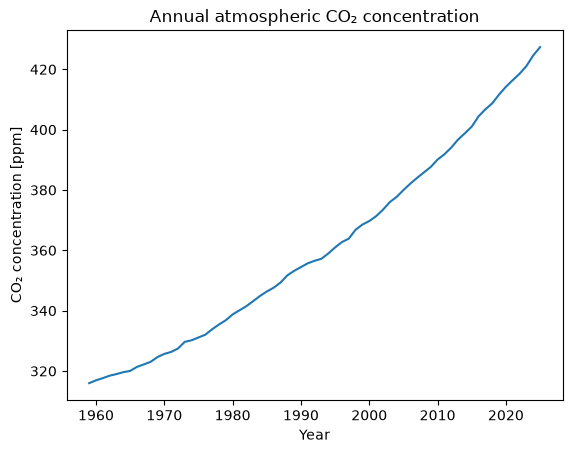

In [37]:
co2_data = pd.read_csv("data/co2_annual.dat", sep=r"\s+", comment="#")
temp_data = pd.read_csv("data/gistemp_annual.dat", sep=r"\s+", comment="#")


co2_year = co2_data["Year"]
co2_ppm = co2_data["CO2_ppm"]

plt.plot(co2_year, co2_ppm)
plt.xlabel("Year")
plt.ylabel("CO₂ concentration [ppm]")
plt.title("Annual atmospheric CO₂ concentration")
plt.show()

# Interpolating function using numpy
def co2_at_time(t):
    return np.interp(t, co2_year, co2_ppm)

# Forcing law: finding forcing from CO2 concentration
def co2_forcing_at_time(t):
    co2 = co2_at_time(t)
    return 5.35 * np.log(co2 / 280.0)

Figure 5: Annual mean $\text{CO}_2$ concentration at Mauna Loa [[6]](#source-6).

The CO₂ record shows an increasing atmospheric CO₂ concentration from 1959
to 2025. Since the ODE solver can evaluate the model at times between the
yearly measurements, linear interpolation is used to estimate the CO₂
concentration at any time $t$. This value is then used in the forcing law from 3.1 to
calculate the radiative forcing.

### 3.3 Fitting $\lambda$ and $\gamma$

We take the observed temperatures from 1959 to 2025 and start both boxes at the 1959 anomaly.

In [38]:
temp_fit = temp_data[
    (temp_data["Year"] >= 1959) &
    (temp_data["Year"] <= 2025)
]

t_data = temp_fit["Year"].to_numpy()
T_data_obs = temp_fit["Anomaly_C"].to_numpy()

y0 = [T_data_obs[0], T_data_obs[0]]

In [39]:
model = TwoBoxModel()

def model_temperature(t, lam, gamma):
    model.lam = lam
    model.gamma = gamma

    solution = solve_reference(
        ebm_rhs,
        y0,
        t,
        model,
        co2_forcing_at_time
    )

    return solution[:, 0]

popt, pcov = curve_fit(
    model_temperature,
    t_data,
    T_data_obs,
    p0=[1.13, 0.73],
    method="trf",
    diff_step=1e-3,
    x_scale="jac",
    max_nfev=2000,
)

fitted_lam = popt[0]
fitted_gamma = popt[1]

In [40]:
T_model = model_temperature(
    t_data,
    fitted_lam,
    fitted_gamma
)

In [41]:
rmse = np.sqrt(np.mean((T_model - T_data_obs)**2))

In [42]:
F2x = 5.35 * np.log(2)
ecs = F2x / fitted_lam

In [43]:
print(f"Fitted lambda: {fitted_lam:.2f} W/(m²K)")
print(f"Fitted gamma: {fitted_gamma:.2f} W/(m²K)")
print(f"RMSE: {rmse:.3f} °C")
print(f"ECS: {ecs:.2f} °C")

Fitted lambda: -1.21 W/(m²K)
Fitted gamma: 5829.00 W/(m²K)
RMSE: 0.108 °C
ECS: -3.06 °C


The unrestricted fit gave approximately

$$
\lambda = -1.21 \text{ W/(m}^2\text{K)}
$$

and

$$
\gamma = 5.83 \times 10^3 \text{ W/(m}^2\text{K)}.
$$

The RMSE was approximately $0.108^\circ C$, which means that the model can
fit the observed temperatures reasonably closely. However, the fitted
parameters are not physically meaningful. The fitted value of $\lambda$ is
negative, while it represents radiative damping in the model, and the fitted
value of $\gamma$ is extremely large compared with the default value of
$0.73$.

The fitted value of $\lambda$ gives an ECS of approximately

$$
ECS = -3.06^\circ C,
$$

which is also not physically reasonable for this model. This shows that a
small fitting error does not necessarily mean that the fitted parameters have
a realistic physical interpretation.

### 3.4 Fitting $\lambda$ with $\gamma$ fixed, and residuals

Now, $\gamma$ is fixed at 0.73 W/(m²K) and only $\lambda$ is fitted, with the bounds $0<\lambda<5.4$ W/(m²K) [[1]](#source-1). We then plot the model together with the observations, and the residual $r(t)=T_{model}(t)-T_{data}(t)$.

In [44]:
model = TwoBoxModel()

def model_temperature_lam(t, lam):
    model.lam = lam
    model.gamma = 0.73

    solution = solve_reference(
        ebm_rhs,
        y0,
        t,
        model,
        co2_forcing_at_time
    )

    return solution[:, 0]

In [45]:
popt_lam, pcov_lam = curve_fit(
    model_temperature_lam,
    t_data,
    T_data_obs,
    p0=[1.13],
    bounds=(1e-6, 5.4),
    method="trf",
    diff_step=1e-3,
    x_scale="jac",
    max_nfev=2000,
)

fitted_lam_2 = popt_lam[0]

In [46]:
T_model_2 = model_temperature_lam(
    t_data,
    fitted_lam_2
)

rmse_2 = np.sqrt(
    np.mean((T_model_2 - T_data_obs)**2)
)

F2x = 5.35 * np.log(2)
ecs_2 = F2x / fitted_lam_2

print(f"Fitted lambda: {fitted_lam_2:.2f}")
print(f"RMSE: {rmse_2:.3f} °C")
print(f"ECS: {ecs_2:.2f} °C")

Fitted lambda: 2.09
RMSE: 0.209 °C
ECS: 1.77 °C


The fitted value of $\lambda = 2.09$ W/(m²K) gives an ECS of approximately
$1.77^\circ C$. This is below the IPCC AR6 likely range of
$2.5$–$4^\circ C$. This suggests that although the
CO₂-only model follows the general warming trend, the fitted climate
sensitivity is lower than the expected range.

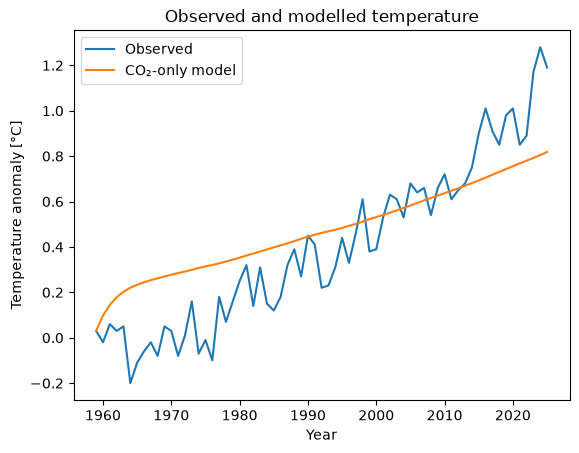

In [47]:
plt.plot(t_data, T_data_obs, label="Observed")
plt.plot(t_data, T_model_2, label="CO₂-only model")

plt.xlabel("Year")
plt.ylabel("Temperature anomaly [°C]")
plt.title("Observed and modelled temperature")
plt.legend()

plt.show()

Figure 6: Observed temperature anomaly [[5]](#source-5) and the $\text{CO}_2$-only model with $\gamma$ fixed.

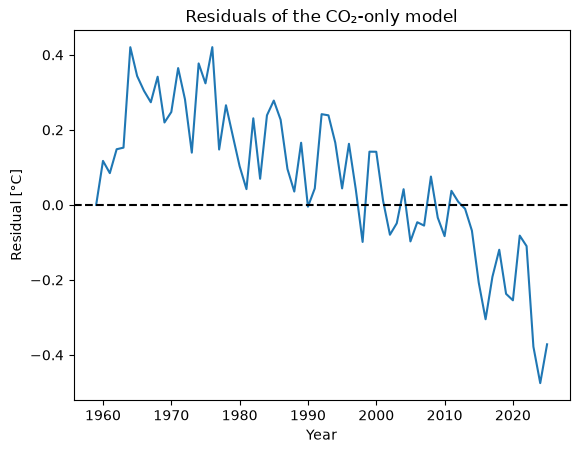

In [48]:
residuals = T_model_2 - T_data_obs

plt.plot(t_data, residuals)
plt.axhline(0, color="black", linestyle="--")

plt.xlabel("Year")
plt.ylabel("Residual [°C]")
plt.title("Residuals of the CO₂-only model")

plt.show()

Figure 7: Residuals of the $\text{CO}_2$-only model.



The CO₂-only model captures the general warming trend from 1959 to 2025, but it does not match the observed temperature very well during all periods. The model gives a smooth increase in temperature, while the observed temperature has much more variation from year to year.

The residual plot shows that the errors are systematic rather than random. In the earlier part of the period, especially around the 1960s to 1980s, the residuals are mostly positive. Since the residual is defined as

$$
r(t) = T_{model}(t) - T_{data}(t),
$$

this means that the model generally predicts a higher temperature than what was observed during this period.

Around the 1990s and 2000s, the residuals are closer to zero, meaning that the model agrees better with the observations. Towards the most recent years, the residuals become mostly negative. This means that the observed temperature is increasing faster than the CO₂-only model predicts.

The clear pattern in the residuals suggests that CO₂ forcing alone does not explain all of the observed temperature changes. There are probably other effects missing from the model that change over time.

### 3.5 Conclusion

Every doubling of $\text{CO}_2$ gives the same increase in forcing. Fitting both $\lambda$ and $\gamma$ gave a small RMSE of $0.108^\circ C$, but parameters that are not physical. With $\gamma$ fixed, we got $\lambda=2.09$ W/(m²K) and an ECS of $1.77^\circ C$, below the IPCC range, and the residuals were systematic. $\text{CO}_2$ alone does not explain the observed warming.

## 4. What is the model missing? Adding aerosol cooling

A fitted parameter can make up for physics that the model is missing. $\lambda=2.09$ from earlier is a compromise between the cool middle of the record and the fast warming at the end. We now test if a negative forcing from aerosols can explain this systematic mismatch.

### 4.1 The aerosol forcing

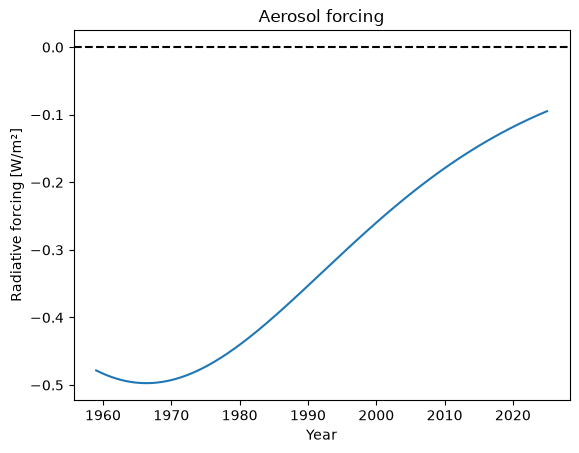

Strongest aerosol forcing: -0.49714589693658223
Year: 1966.4068136272545


In [49]:
def aerosol_forcing(t, B):
    rise = 1 / (1 + np.exp(-(t - 1950) / 15))
    fall = 1 / (1 + np.exp((t - 1980) / 20))

    return -B * rise * fall

B = 1

t = np.linspace(1959, 2025, 500)

F_aerosol = aerosol_forcing(t, B)

plt.plot(t, F_aerosol)
plt.axhline(0, color="black", linestyle="--")

plt.xlabel("Year")
plt.ylabel("Radiative forcing [W/m²]")
plt.title("Aerosol forcing")

plt.show()

index = np.argmin(F_aerosol)

print("Strongest aerosol forcing:", F_aerosol[index])
print("Year:", t[index])


Figure 8: Aerosol forcing with $B=1$ W/m².

The two fractions in the aerosol forcing equation are dimensionless.
Therefore, $B$ must have units of W/m² so that
$F_{\text{aerosol}}$ also has units of W/m².

For $B=1$ W/m², the aerosol forcing has its largest magnitude around
1966, where it is approximately $-0.50$ W/m².

It is expected that the temperature trajectory changes the most during the middle part
of the record, around the 1960s to 1980s. This is where the aerosol forcing is
strongest and most negative, so it reduces the total radiative forcing the most.

Therefore, the model should predict lower temperatures in this period compared
with the CO₂-only model. The effect on temperature may also continue for some
time after the strongest aerosol forcing because the climate system does not
respond instantly.

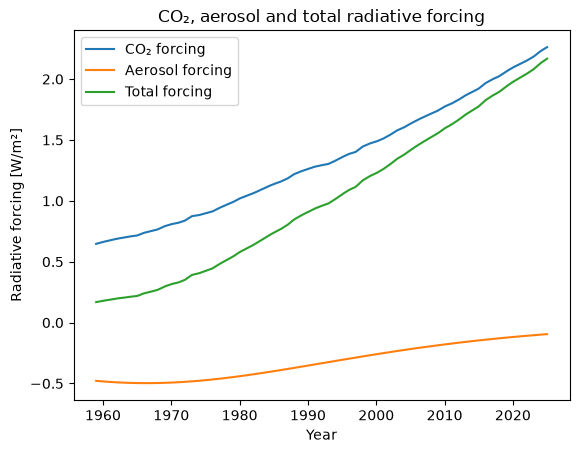

In [50]:
F_co2 = co2_forcing_at_time(t)
F_total = F_co2 + F_aerosol

plt.plot(t, F_co2, label="CO₂ forcing")
plt.plot(t, F_aerosol, label="Aerosol forcing")
plt.plot(t, F_total, label="Total forcing")

plt.xlabel("Year")
plt.ylabel("Radiative forcing [W/m²]")
plt.title("CO₂, aerosol and total radiative forcing")
plt.legend()

plt.show()

Figure 9: $\text{CO}_2$, aerosol and total forcing with $B=1$ W/m².

### 4.2 Fitting $\gamma$ and $B$

We use the same data, initial state and fitting setup as in 3.3, but fix $\lambda=1.13$ W/(m²K) and fit $\gamma$ and $B$, with the bounds $0.1\le\gamma\le2.0$ W/(m²K) and $0\le B\le3.0 \text{W/m}^2$. The total forcing is the $\text{CO}_2$ forcing plus the aerosol forcing. We then compare both models and their residuals.

In [51]:
def model_temperature_aerosol(t, gamma, B):
    model.lam = 1.13
    model.gamma = gamma

    def total_forcing(time):
        return (
            co2_forcing_at_time(time)
            + aerosol_forcing(time, B)
        )

    solution = solve_reference(
        ebm_rhs,
        y0,
        t,
        model,
        total_forcing
    )

    return solution[:, 0]

In [52]:
popt_aerosol, pcov_aerosol = curve_fit(
    model_temperature_aerosol,
    t_data,
    T_data_obs,
    p0=[0.73, 1.0],
    bounds=(
        [0.1, 0.0],
        [2.0, 3.0]
    ),
    method="trf",
    diff_step=1e-3,
    x_scale="jac",
    max_nfev=2000
)

fitted_gamma = popt_aerosol[0]
fitted_B = popt_aerosol[1]

In [53]:
T_aerosol = model_temperature_aerosol(
    t_data,
    fitted_gamma,
    fitted_B
)

rmse_aerosol = np.sqrt(
    np.mean((T_aerosol - T_data_obs)**2)
)


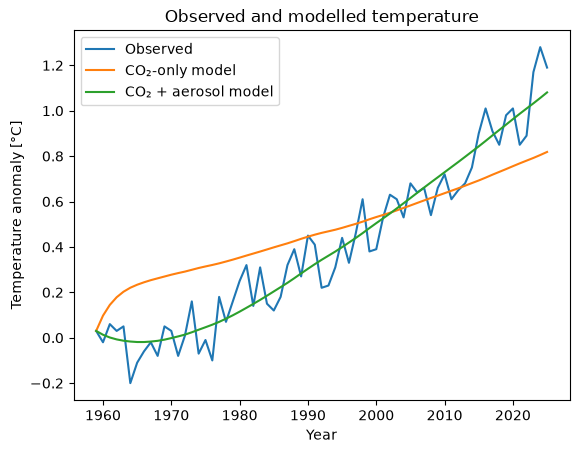

In [54]:
plt.plot(t_data, T_data_obs, label="Observed")

plt.plot(t_data, T_model_2, label="CO₂-only model")

plt.plot(t_data, T_aerosol, label="CO₂ + aerosol model")

plt.xlabel("Year")
plt.ylabel("Temperature anomaly [°C]")
plt.title("Observed and modelled temperature")
plt.legend()

plt.show()

Figure 10: Observed temperature anomaly with the $\text{CO}_2$-only and $\text{CO}_2$ + aerosol models.

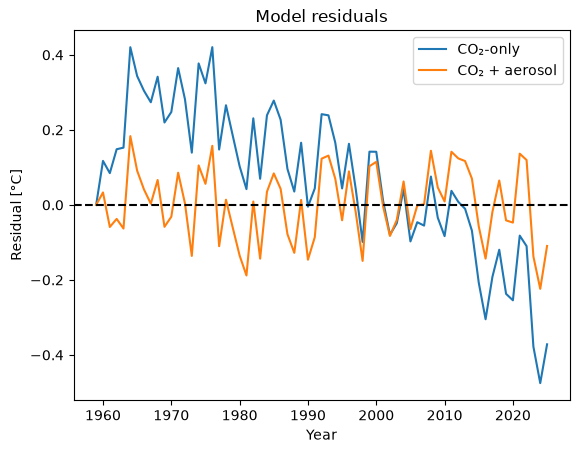

In [55]:
residuals_aerosol = T_aerosol - T_data_obs

plt.plot(t_data, residuals, label="CO₂-only")

plt.plot(t_data, residuals_aerosol, label="CO₂ + aerosol")

plt.axhline(0, color="black", linestyle="--")

plt.xlabel("Year")
plt.ylabel("Residual [°C]")
plt.title("Model residuals")
plt.legend()

plt.show()

Figure 11: Residuals of the $\text{CO}_2$-only and $\text{CO}_2$ + aerosol models.

In [56]:
print("Fitted gamma:", fitted_gamma)
print("Fitted B:", fitted_B)
print("RMSE:", rmse_aerosol)

Fitted gamma: 0.8049255589769083
Fitted B: 1.5823271266254162
RMSE: 0.0956098149383332


### 4.3 Is the aerosol model better?

As shown in the figures above, the CO₂ + aerosol model represents the observed
temperature data more accurately than the CO₂-only model. The residuals also
have less of a clear systematic pattern and are generally closer to zero.

The fitted values were

$$
\gamma \approx 0.80 \text{ W/(m}^2\text{K)}
$$

and

$$
B \approx 1.58 \text{ W/m}^2,
$$

with an RMSE of approximately $0.096^\circ C$.

The fitted value of $\gamma$ also seems reasonable since it is fairly close to
the default value of 0.73. The positive value of $B$ means that the aerosol
forcing gives a cooling effect, which is the physical effect we expected when
adding aerosols to the model.

Therefore, the aerosol model seems to be an improvement over the CO₂-only
model. The aerosol cooling helps explain some of the temperature variation
that the CO₂-only model was not able to reproduce.

However, the better fit does not prove that this specific aerosol model is
correct. The aerosol forcing used here is only an approximate model, and adding
another fitted parameter also gives the model more flexibility to match the
observations. The improved RMSE and residuals show that the added forcing can
explain some of the missing behaviour, but they do not prove that the chosen
aerosol forcing is the true explanation.

### 4.4 Conclusion

Adding an aerosol cooling that is strongest in the 1960s made the model follow the observations much better than the $\text{CO}_2$-only model, with about half the RMSE and no clear pattern left in the residuals. The fitted parameters are also physically reasonable. The systematic residuals from the last chapter pointed us to the missing forcing, but a better fit alone does not prove that the aerosol model is correct.

## 5. Nonlinear feedback and hysteresis

So far the model has been linear, and for each constant forcing there is only one equilibrium, $T_{eq}=F_0/\lambda$. Now, we add an ice-albedo feedback. When the planet warms, ice and snow melt, less sunlight is reflected, and the planet warms even more. This makes one of the energy flows depend on the temperature, nonlinearly.

We will start with running a temporary $\text{CO}_2$ increase with the linear model. Then we implement an albedo that depends on temperature, add it to the energy balance, and repeat the same run with the nonlinear model to see if it returns to what it was. The albedo function and its parameters are only meant to illustrate the feedback, so any threshold we find belongs to this simple model and is not an estimate of a real climate threshold [[1]](#source-1).

### 5.1 Linear model with a temporary CO₂ increase

We use the $\text{CO}_2$ pathway from the project description [[1]](#source-1), where the concentration rises from 280 ppm to a peak $c_{max}$, stays there for 20 years, and falls back to 280 ppm:

$$
c(t; c_{max}) =
\begin{cases}
280 + (c_{max}-280)\,t/100, & 0 \le t < 100 \\
c_{max}, & 100 \le t < 120 \\
c_{max} - (c_{max}-280)(t-120)/100, & 120 \le t < 220 \\
280, & t \ge 220
\end{cases}
$$

with $c_{max}=560$ ppm. The concentration is turned into a forcing with the forcing law $F(t)=5.35\ln\left(c(t)/280\right)$ [[3]](#source-3).

To predict, with a rising $\text{CO}_2$, the upper box should warm quickly and the deep ocean much slower, because of the large heat capacity. The peak only lasts 20 years, so the upper box will not reach the $3.28 \text{ K}$ equilibrium from 2.2. When the forcing is gone, the linear model has only one equilibrium, $T=T_0=0$, so both boxes should go back to zero. This should happen slowly, since  the deep ocean has to give back the heat it has stored.

In the implementation below, `co2_pathway` is the pathway above written with if-tests, and `co2_forcing` is the forcing law from 2.2. `run_pathway` combines them into a forcing that only depends on time, which is what `ebm_rhs` expects, and runs our RK4 solver from $T=T_0=0$. We run 1500 years with $h=0.5$ years, which is stable based on 2.3.

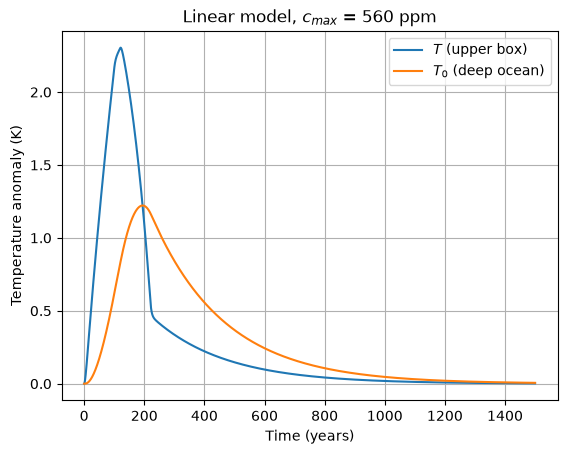

Peak T = 2.3 K
t = 220 years: T = 0.573 K, T0 = 1.17 K
t = 500 years: T = 0.147 K, T0 = 0.368 K
t = 1000 years: T = 0.019 K, T0 = 0.046 K
t = 1500 years: T = 0.002 K, T0 = 0.006 K


In [57]:
def co2_pathway(t, c_max):
    if t < 100:
        return 280 + (c_max - 280) * t / 100  # CO2 rises
    elif t < 120:
        return c_max  # CO2 is held at the peak
    elif t < 220:
        return c_max - (c_max - 280) * (t - 120) / 100  # CO2 falls back
    else:
        return 280.0  # back to pre-industrial


def run_pathway(rhs, model, c_max, t):
    def forcing(time):
        return co2_forcing(co2_pathway(time, c_max))

    y0 = np.array([0.0, 0.0])  # start in pre-industrial equilibrium
    return solver(rhs, y0, t, model, forcing)


model_linear = TwoBoxModel()
t_path = np.arange(0, 1500.5, 0.5)  # 1500 years with h = 0.5 year
solution_linear = run_pathway(ebm_rhs, model_linear, 560, t_path)

plt.plot(t_path, solution_linear[:, 0], label="$T$ (upper box)")
plt.plot(t_path, solution_linear[:, 1], label="$T_0$ (deep ocean)")
plt.xlabel("Time (years)")
plt.ylabel("Temperature anomaly (K)")
plt.title("Linear model, $c_{max}$ = 560 ppm")
plt.legend()
plt.grid()
plt.show()

print("Peak T =", round(np.max(solution_linear[:, 0]), 2), "K")
for year in [220, 500, 1000, 1500]:
    T, T0 = solution_linear[int(year / 0.5)]
    print("t =", year, "years: T =", round(T, 3), "K, T0 =", round(T0, 3), "K")

Figure 12: Upper box and deep ocean temperature in the linear model with $c_{max}=560$ ppm.

The upper box warms quickly to a peak of $2.30$ K, well below the $3.28$ K equilibrium, since the peak only lasts 20 years. When the forcing is gone after 220 years, the upper box first drops quickly to around $0.5$ K, but then cools very slowly. This long cooling tail comes from the deep ocean. At $t=220$ years the deep ocean is at $1.17$ K and the upper box only at $0.57$ K, so $T_0>T$, and the heat exchange $\gamma(T-T_0)$ changes direction, as we saw in 1.1. Heat then flows from the deep ocean back into the upper box, which is the only box that can lose heat to space through $\lambda T$. Since $C_0=106$ is much larger than $C=7.3$, it takes a long time for the deep ocean to give back its heat, and this keeps the upper box warm. After 1000 years $T$ is $0.019$ K and after 1500 years $0.002$ K.

The linear model returns to its initial state after the temporary $\text{CO}_2$ increase, but it takes over a thousand years because of the slow deep ocean.

### 5.2 Temperature-dependent albedo

In the first chapter, we had a constant albedo, $\alpha=0.30$. To include the ice-albedo feedback, we let the albedo depend on the temperature anomaly, using the function from the project description [[1]](#source-1):

$$
\alpha(T)=\alpha_{min}+\frac{\alpha_{max}-\alpha_{min}}{2}\left[1-\tanh\left(\frac{T-T_c}{\Delta T}\right)\right],
$$

with $\alpha_{min}=0.28$, $\alpha_{max}=0.305$, $T_c=2.08$ K and $\Delta T=3.0$ K [[1]](#source-1). For low temperatures $\alpha\to\alpha_{max}$ (more ice), and for high temperatures $\alpha\to\alpha_{min}$ (less ice). $T_c$ is where the albedo changes fastest, and $\Delta T$ decides how wide the change is.

For $T=0$ we get

$$
\alpha(0) = 0.28+\frac{0.025}{2}\left[1-\tanh\left(\frac{-2.08}{3.0}\right)\right] \\
= 0.28+0.0125\cdot(1+0.600) \\
\approx0.300
$$

since tanh is an odd function, $\tanh(-x)=-\tanh(x)$. The model therefore starts with the same albedo, so the pre-industrial state is the same as before.

The albedo parameters are added to a new `TwoBoxModel` object, so the other parameters are still only defined in one place. The code checks $\alpha(0)$ numerically and plots $\alpha(T)$ for $-10\le T\le15$ K.

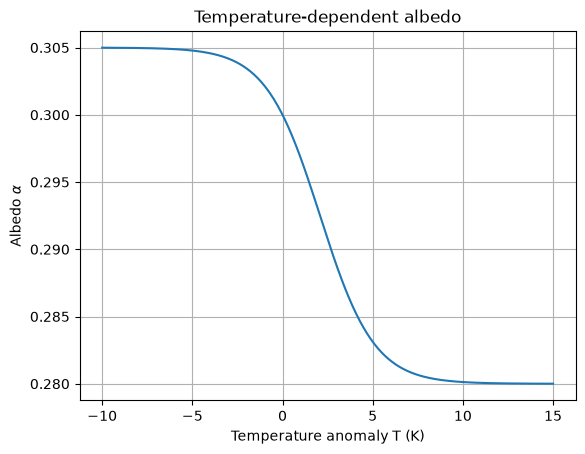

alpha(0) = 0.3


In [58]:
# A new model object with the albedo parameters from the project description added
model_albedo = TwoBoxModel()
model_albedo.S0 = 1361.0
model_albedo.alpha_min = 0.28
model_albedo.alpha_max = 0.305
model_albedo.T_c = 2.08
model_albedo.delta_T = 3.0


def albedo(T, model):
    return model.alpha_min + (model.alpha_max - model.alpha_min) / 2 * (1 - np.tanh((T - model.T_c) / model.delta_T))


T_values = np.linspace(-10, 15, 500)
plt.plot(T_values, albedo(T_values, model_albedo))
plt.xlabel("Temperature anomaly T (K)")
plt.ylabel(r"Albedo $\alpha$")
plt.title("Temperature-dependent albedo")
plt.grid()
plt.show()

print("alpha(0) =", round(albedo(0, model_albedo), 4))

Figure 13: The temperature-dependent albedo $\alpha(T)$ for $-10 \le T \le 15$ K.

The code gives $\alpha(0)=0.30$, the same as our calculation. Figure 13 shows that the albedo stays between $\alpha_{min}$ and $\alpha_{max}$, and changes the most around $T_c=2.08$ K.

A smooth and bounded function like this is more physical than the alternatives. A straight line, $\alpha=\alpha(0)-kT$, would keep decreasing forever. For a large enough warming it would become negative, and for a strong cooling it would go above 1, which is impossible since the albedo is a fraction between 0 and 1. Physically, when all the ice has melted there is no more ice to lose, so the albedo has to level off, which the tanh does. A step function, where the albedo jumps from $\alpha_{max}$ to $\alpha_{min}$ at one temperature, would mean that all the ice on the whole planet melts at exactly the same temperature. In reality ice melts gradually, starting where it is warmest, so the albedo should change smoothly over a range of temperatures.

The tanh function lets the albedo decrease when the planet warms, which gives a positive feedback, but only within realistic limits.

### 5.3 Albedo forcing and the new energy balance

The albedo forcing and the new upper-box balance are [[1]](#source-1):

$$
F_{albedo}(T)=\frac{S_0}{4}\bigl[\alpha(0)-\alpha(T)\bigr], \qquad C\frac{dT}{dt}=F(t)+F_{albedo}(T)-\lambda T-\gamma(T-T_0).
$$

The deep-ocean equation is unchanged.

To check the units, $S_0$ is in $\text{W/m}^2$, and the albedo is a fraction without units, so $\alpha(0)-\alpha(T)$ has no unit either. $F_{albedo}$ is therefore in $\text{W/m}^2$, the same as $F(t)$, $\lambda T$ and $\gamma(T-T_0)$ in 1.2, so the new term fits into the energy balance.

At $T=0$ the two albedos are the same, so $F_{albedo}(0)=\frac{S_0}{4}\bigl[\alpha(0)-\alpha(0)\bigr]=0$. The albedo forcing therefore only adds energy when the temperature is different from pre-industrial.

In the code, `ebm_rhs_albedo` first calls `ebm_rhs` from chapter 2.1 to get the rates of the linear model, and then adds the albedo forcing divided by $C$ to the rate of the upper box, since it enters the upper-box balance in the same way as $F(t)$. It takes the same arguments, so it can be used directly with our solver.

In [59]:
def albedo_forcing(T, model):
    return model.S0 / 4 * (albedo(0, model) - albedo(T, model))


def ebm_rhs_albedo(y, t, model, forcing):
    dT_dt, dT0_dt = ebm_rhs(y, t, model, forcing)  # linear model from 2.1
    dT_dt += albedo_forcing(y[0], model) / model.C  # albedo forcing only enters the upper box
    return np.array([dT_dt, dT0_dt])


print("F_albedo(0) =", albedo_forcing(0, model_albedo), "W/m^2")

F_albedo(0) = 0.0 W/m^2


This confirms that $F_{albedo}(0)=0$. In short, the new energy balance has the same units as before, but now one of the energy flows depends on the temperature itself, which makes the model nonlinear.

### 5.4 Nonlinear model with the same CO₂ pathway

We now repeat the run from 5.1 with the nonlinear model, with the same pathway, $c_{max}=560$ ppm, start at $T=T_0=0$ and time steps. Since warming lowers the albedo and adds extra energy, we expect the nonlinear model to warm more than the linear one.

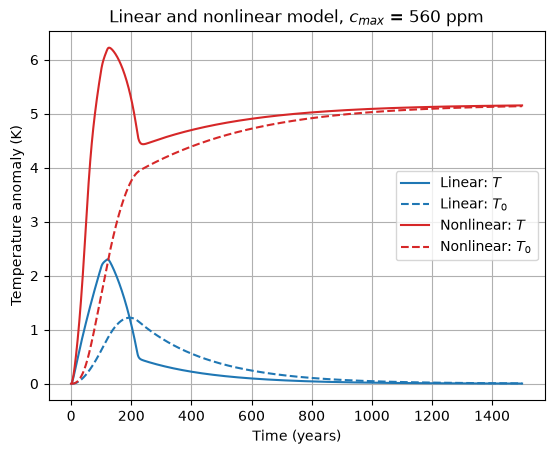

Peak T, nonlinear model: 6.22 K
After 1500 years, nonlinear model: T = 5.154 K, T0 = 5.14 K


In [60]:
solution_nonlinear = run_pathway(ebm_rhs_albedo, model_albedo, 560, t_path)

plt.plot(t_path, solution_linear[:, 0], "C0", label="Linear: $T$")
plt.plot(t_path, solution_linear[:, 1], "C0--", label="Linear: $T_0$")
plt.plot(t_path, solution_nonlinear[:, 0], "C3", label="Nonlinear: $T$")
plt.plot(t_path, solution_nonlinear[:, 1], "C3--", label="Nonlinear: $T_0$")
plt.xlabel("Time (years)")
plt.ylabel("Temperature anomaly (K)")
plt.title("Linear and nonlinear model, $c_{max}$ = 560 ppm")
plt.legend()
plt.grid()
plt.show()

print("Peak T, nonlinear model:", round(np.max(solution_nonlinear[:, 0]), 2), "K")
print("After 1500 years, nonlinear model: T =", round(solution_nonlinear[-1, 0], 3), "K, T0 =", round(solution_nonlinear[-1, 1], 3), "K")

Figure 14: Linear (blue) and nonlinear (red) model with $c_{max}=560$ ppm. Solid lines are the upper box and dashed lines the deep ocean.

The nonlinear model warms much more, with a peak of $6.22$ K compared to $2.30$ K. More importantly, it does not return to its initial state. After the $\text{CO}_2$ is back at 280 ppm, the upper box only cools to about $4.4$ K before it starts warming again, and after 1500 years both boxes are at about $5.15$ K. After the $\text{CO}_2$ forcing is gone, the albedo forcing is large enough to keep the planet warm on its own, so the model stays in a warm state even though the $\text{CO}_2$ forcing is the same as at the start.

To locate the transition, we repeat the run with smaller peaks, $c_{max}$ from 300 to 560 ppm. We run each for 3000 years with $h=1$ year, since close to the transition the model can change very slowly, and check if $T$ goes back to zero or not.

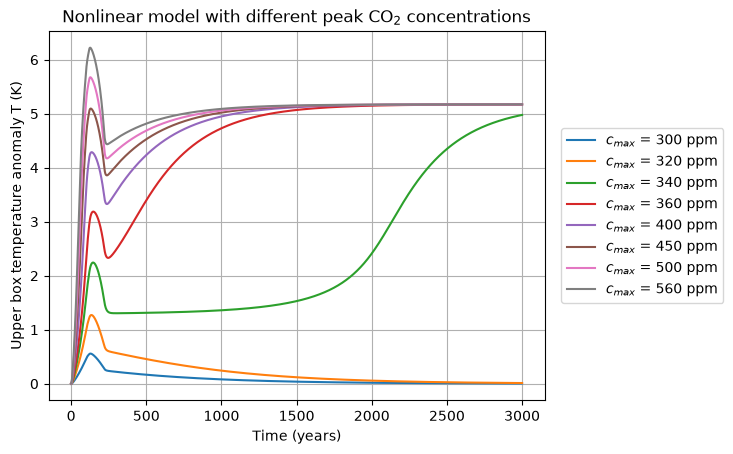

c_max = 300 ppm: T after 3000 years = 0.004 K
c_max = 320 ppm: T after 3000 years = 0.012 K
c_max = 340 ppm: T after 3000 years = 4.977 K
c_max = 360 ppm: T after 3000 years = 5.172 K
c_max = 400 ppm: T after 3000 years = 5.173 K
c_max = 450 ppm: T after 3000 years = 5.173 K
c_max = 500 ppm: T after 3000 years = 5.173 K
c_max = 560 ppm: T after 3000 years = 5.173 K


In [61]:
c_max_values = [300, 320, 340, 360, 400, 450, 500, 560]
t_scan = np.arange(0, 3000.5, 1.0)  # 3000 years with h = 1 year
final_lines = []  # printed after the plot

for c_max in c_max_values:
    solution = run_pathway(ebm_rhs_albedo, model_albedo, c_max, t_scan)
    plt.plot(t_scan, solution[:, 0], label="$c_{max}$ = " + str(c_max) + " ppm")
    final_lines.append("c_max = " + str(c_max) + " ppm: T after 3000 years = " + str(round(solution[-1, 0], 3)) + " K")

plt.xlabel("Time (years)")
plt.ylabel("Upper box temperature anomaly T (K)")
plt.title("Nonlinear model with different peak CO$_2$ concentrations")
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.grid()
plt.show()

for line in final_lines:
    print(line)

Figure 15: Upper box temperature anomaly in the nonlinear model for different peak $\text{CO}_2$ concentrations $c_{max}$.

For $c_{max}=300$ and $320$ ppm the model goes back to zero, while for $c_{max}=340$ ppm and above it goes to the same warm state at about $5.17$ K (with 340 ppm it is at $4.98$ K after 3000 years and still rising). The transition is therefore between 320 and 340 ppm. Above the transition, the final temperature does not depend on how high the peak was, only on whether the peak was high enough. With $c_{max}=340$ ppm the model stays at about 1.3 K for over a thousand years before it warms, which is why we needed longer runs than 1500 years. This threshold belongs to this simplified model, and does not say anything about where a real climate threshold would be [[1]](#source-1).

In short, with the albedo feedback a temporary $\text{CO}_2$ increase above the transition pushes the model into a warm state that it stays in after the forcing is removed.

### 5.5 Conclusion

We compared the linear model with a nonlinear model that includes an ice-albedo feedback, using a temporary $\text{CO}_2$ increase. The linear model returns to its initial state when the forcing is removed, but slowly, because the deep ocean gives back the heat it has stored.

The nonlinear model does not return. With $c_{max}=560$ ppm it ends in a warm state at about $5.17$ K, even after the $\text{CO}_2$ is back at 280 ppm. By repeating the run with smaller peaks, we found that the transition is between 320 and 340 ppm in this model. Below it the model returns to zero, and above it the model stays warm. So the state the model ends in depends on the forcing history and not only on the forcing now, which is hysteresis.

## Summary

In this project we used a simple two-box model to study how the climate responds to changes in $\text{CO}_2$.

We checked the units of the model, and found that an Earth without an atmosphere would only be $-18.6\ ^\circ\text{C}$.

Then, we built our own ODE solver and tested it against the equilibrium we found by hand and against SciPy's Radau solver, with very small errors. The stability test showed that Forward Euler blows up for steps larger than 7–8 years, even though the physical model is stable.

When we fitted the model to real temperatures, a free fit of both $\lambda$ and $\gamma$ gave a small error, but parameters that are not physical. With $\gamma$ fixed, the climate sensitivity was below the IPCC range and the residuals showed a clear systematic pattern, so $\text{CO}_2$ alone does not explain the observed warming.

Adding an aerosol cooling removed most of this pattern and halved the error, but a better fit alone does not prove that the aerosol model is correct.

Finally, the ice-albedo feedback made the model nonlinear. The linear model always returns to where it started when the forcing is removed, but the nonlinear model stays in a warm state if the $\text{CO}_2$ peak is above a threshold between 320 and 340 ppm.

In all, the project shows that even a simple model can explain a lot of the main behaviour of the climate, as long as we check the model and the numerics carefully before trusting the results.

## Reflection



### Jone

In Exercises 3 and 4, I learned that getting a model to fit the data well does not necessarily mean that the model or the fitted parameters are physically correct. In Exercise 3, the unrestricted fit gave a fairly low RMSE, but the fitted values of $\lambda$ and $\gamma$ were unrealistic. This showed me why it is important to look at the meaning of the parameters and not only the numerical error.

When $\gamma$ was fixed and only $\lambda$ was fitted, the model captured the general warming trend, but the residuals showed a clear systematic pattern. The calculated ECS was also below the IPCC range, which suggested that the simple CO₂-only model was missing some important effects.

In Exercise 4, adding aerosol cooling made the model fit the observed temperature better. The RMSE decreased from about $0.209^\circ C$ for the CO₂-only model to about $0.096^\circ C$, and the residuals became less systematic.

This helped me understand how residuals can be used to identify missing parts of a model. I also learned that even though adding aerosols improved the fit, this does not prove that the exact aerosol model is correct, since the aerosol forcing used here is only an approximation and adding another parameter gives the model more flexibility.

Overall, these exercises gave me a better understanding of parameter fitting, residuals, and the difference between a model that fits the data and a model that also makes physical sense.

### Petter

Doing exercises 1, 2 and 5, the most useful thing for me was to see how important it is to check a numerical solution before trusting it.

Building the solver so it does not know anything about the climate, and then testing it against an equilibrium found by hand and against a reference solver, made it much easier to trust the later results. The stability test was also interesting, since it showed that Forward Euler can blow up even when the physical model is completely stable, only because the step is too long compared to how fast the upper box changes. In Exercise 5, I learned that a nonlinear model can have more than one stable state, and that near the threshold the model can stay almost unchanged for a very long time, so a short simulation can give the wrong answer.

Reusing the same functions (`ebm_rhs`, `solver`, `solve_reference`) through the whole project worked well, and made Exercise 5 quick to implement.

We could have started working together a bit earlier. Though we decided early to stay in a group for project 2, we started late with splitting the work. It would be better to have a few more days to discuss the report to make sure we were happy with the final version. I also spent time at first on overcomplicating some of the explanations and implementations in chapters 1 and 2, but was finally able to simplify them for more clarity. This could have been avoided for a more effective process.

The project description was mostly clear, and it was nice that the climate physics was explained along the way. One thing that was confusing was in exercise 5. The task says to simulate at least 1000 years, but for me the model needed more than 1500 years before it was clear which state it ended up in, so this could have been mentioned in the task.

To improve the process for our next project, we will divide the tasks at the start, and make sure we share our progress more often. We will also leave enough time at the end to check that the code and reported results agree, and simplify any explanations that are too complicated, or even too brief. This would make it easier to catch any problems before the deadline.

## References

[1] <a id="source-1"></a>Aksel Hiorth. The Planet in a Box: An Energy Balance Model of Global Warming (Project 2 description), 2026.

[2] <a id="source-2"></a>Olivier Geoffroy, David Saint-Martin, Dirk J. L. Olivie, Aurore Voldoire, Gilles Bellon, and Sophie Tyteca. Transient climate response in a two-layer energy-balance model. part i: Analytical solution and parameter calibration using cmip5 aogcm experiments, 2013.

[3] <a id="source-3"></a>Gunnar Myhre, Eleanor J. Highwood, Keith P. Shine, and Frode Stordal. New estimates of radiative forcing due to well mixed greenhouse gases, 1998.

[4] <a id="source-4"></a>V. Masson-Delmotte, P. Zhai, A. Pirani, S. L. Connors, C. Pean, S. Berger, N. Caud, Y. Chen, L. Goldfarb, M. I. Gomis, M. Huang, K. Leitzell, E. Lonnoy, J. B. R. Matthews, T. K. Maycock, T. Waterfield, O. Yelekci, R. Yu, and B. Zhou (eds.). Climate Change 2021: the Physical Science Basis. Contribution of Working Group I to the Sixth Assessment Report of the Intergovernmental Panel on Climate Change. Technical report, Cambridge University Press. In Press., August 2021.

[5] <a id="source-5"></a>NASA Goddard Institute for Space Studies. GISS surface temperature analysis (GISTEMP), version 4. https://data.giss.nasa.gov/gistemp/, 2024. 

[6] <a id="source-6"></a>NOAA Global Monitoring Laboratory. Trends in atmospheric carbon dioxide, mauna loa observatory. https://gml.noaa.gov/ccgg/trends/mlo.html, 2025.
